In [1]:
!pip install scikit-learn lightgbm --quiet



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## DATA PROCESSING

In [2]:
# 展示 shape、column
DATA_DIR = "data"
TRAIN_PATH = f"{DATA_DIR}/train.csv"
TEST_PATH  = f"{DATA_DIR}/test.csv"

import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt

print("Reading:", TRAIN_PATH, TEST_PATH)
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test  = pd.read_csv(TEST_PATH,  low_memory=False)
print("Train shape:", train.shape, " Test shape:", test.shape)

display(train.head())


Reading: data/train.csv data/test.csv
Train shape: (97992, 21)  Test shape: (3084, 20)


,rally_uid,sex,match,numberGame,rally_id,strickNumber,scoreSelf,scoreOther,serverGetPoint,gamePlayerId,...,serveId,serveNumber,strickId,handId,strengthId,spinId,pointId,actionId,let,positionId
0,1,1,1,1,1,1,0,0,1,1,...,1,0,1,1,3,5,4,0,0,0
1,1,1,1,1,1,2,0,0,1,2,...,1,1,2,2,2,1,9,4,0,0
2,1,1,1,1,1,3,0,0,1,1,...,1,1,4,1,1,1,7,1,0,0
3,1,1,1,1,1,4,0,0,1,2,...,1,1,4,0,0,0,0,0,0,0
4,1,1,1,1,1,5,0,0,1,1,...,1,1,-1,-1,-1,-1,-1,-1,-1,-1


In [3]:
# ============ 1. 基本排序與下一擊標籤 ============

def has(df, col):
    return col in df.columns

# 修正欄位名稱
if 'strickNumber' in train.columns:
    train['stroke_number'] = train['strickNumber']
if 'strickNumber' in test.columns:
    test['stroke_number'] = test['strickNumber']

# 排序
order_cols = [c for c in ['match_id', 'rally_id', 'stroke_number'] if has(train, c)]
if order_cols:
    train = train.sort_values(order_cols).reset_index(drop=True)
    test = test.sort_values(order_cols).reset_index(drop=True)

group_key = 'rally_id' if has(train, 'rally_id') else None

# 生成標籤
for col in ['actionId', 'pointId']:
    if group_key and has(train, col):
        train[f'next_{col}'] = train.groupby(group_key)[col].shift(-1)

In [4]:
# ============ 2. 增強的序列特徵 ============
print("\n🔧 建立增強序列特徵...")

# 2.1 前K擊特徵（擴展到5擊）
K = 5
for k in range(1, K + 1):
    for col in ['actionId', 'pointId']:
        if group_key and has(train, col):
            train[f'prev{k}_{col}'] = train.groupby(group_key)[col].shift(k)
        if group_key and has(test, col):
            test[f'prev{k}_{col}'] = test.groupby(group_key)[col].shift(k)

# 2.2 動作序列模式特徵
if has(train, 'actionId') and group_key:
    # 連續相同動作計數
    train['action_repeat_count'] = train.groupby([group_key, 'actionId']).cumcount() + 1
    test['action_repeat_count'] = test.groupby([group_key, 'actionId']).cumcount() + 1
    
    # 動作變化指標（前後動作是否相同）
    train['action_changed'] = (train.groupby(group_key)['actionId'].shift(1) != train['actionId']).astype(int)
    test['action_changed'] = (test.groupby(group_key)['actionId'].shift(1) != test['actionId']).astype(int)

# 2.3 落點序列模式
if has(train, 'pointId') and group_key:
    train['point_repeat_count'] = train.groupby([group_key, 'pointId']).cumcount() + 1
    test['point_repeat_count'] = test.groupby([group_key, 'pointId']).cumcount() + 1
    
    train['point_changed'] = (train.groupby(group_key)['pointId'].shift(1) != train['pointId']).astype(int)
    test['point_changed'] = (test.groupby(group_key)['pointId'].shift(1) != test['pointId']).astype(int)


🔧 建立增強序列特徵...


In [5]:
# ============ 3. 比賽情境特徵 ============
print("🏸 建立比賽情境特徵...")

# 3.1 比分特徵
if has(train, 'scoreSelf') and has(train, 'scoreOther'):
    train['score_diff'] = train['scoreSelf'] - train['scoreOther']
    train['score_total'] = train['scoreSelf'] + train['scoreOther']
    train['score_ratio'] = train['scoreSelf'] / (train['scoreOther'] + 1)  # 避免除零
    train['is_leading'] = (train['score_diff'] > 0).astype(int)
    train['is_close_game'] = (abs(train['score_diff']) <= 2).astype(int)
    train['is_game_point'] = ((train['scoreSelf'] >= 20) | (train['scoreOther'] >= 20)).astype(int)

if has(test, 'scoreSelf') and has(test, 'scoreOther'):
    test['score_diff'] = test['scoreSelf'] - test['scoreOther']
    test['score_total'] = test['scoreSelf'] + test['scoreOther']
    test['score_ratio'] = test['scoreSelf'] / (test['scoreOther'] + 1)
    test['is_leading'] = (test['score_diff'] > 0).astype(int)
    test['is_close_game'] = (abs(test['score_diff']) <= 2).astype(int)
    test['is_game_point'] = ((test['scoreSelf'] >= 20) | (test['scoreOther'] >= 20)).astype(int)

# 3.2 回合特徵
if group_key and has(train, 'stroke_number'):
    train['rally_length'] = train.groupby(group_key)['stroke_number'].transform('max')
    train['rally_progress'] = train['stroke_number'] / train['rally_length']
    train['is_early_rally'] = (train['rally_progress'] < 0.3).astype(int)
    train['is_mid_rally'] = ((train['rally_progress'] >= 0.3) & (train['rally_progress'] < 0.7)).astype(int)
    train['is_late_rally'] = (train['rally_progress'] >= 0.7).astype(int)

if group_key and has(test, 'stroke_number'):
    test['rally_length'] = test.groupby(group_key)['stroke_number'].transform('max')
    test['rally_progress'] = test['stroke_number'] / test['rally_length']
    test['is_early_rally'] = (test['rally_progress'] < 0.3).astype(int)
    test['is_mid_rally'] = ((test['rally_progress'] >= 0.3) & (test['rally_progress'] < 0.7)).astype(int)
    test['is_late_rally'] = (test['rally_progress'] >= 0.7).astype(int)


🏸 建立比賽情境特徵...


In [6]:
# ============ 4. 球員特徵 ============
print("👤 建立球員特徵...")

# 4.1 球員編碼
for col in ['sex', 'gamePlayerId', 'gamePlayerOtherId']:
    if has(train, col):
        # 使用 factorize 替代 category codes（更穩定）
        train[col] = pd.factorize(train[col])[0]
    if has(test, col):
        test[col] = pd.factorize(test[col])[0]

# 4.2 球員統計特徵（基於訓練集）
if has(train, 'gamePlayerId') and has(train, 'actionId'):
    # 每位球員最常用的動作
    player_action_stats = train.groupby('gamePlayerId')['actionId'].agg(
        lambda x: x.value_counts().index[0] if len(x) > 0 else -1
    ).to_dict()
    train['player_fav_action'] = train['gamePlayerId'].map(player_action_stats)
    test['player_fav_action'] = test['gamePlayerId'].map(player_action_stats).fillna(-1)

if has(train, 'gamePlayerId') and has(train, 'pointId'):
    # 每位球員最常用的落點
    player_point_stats = train.groupby('gamePlayerId')['pointId'].agg(
        lambda x: x.value_counts().index[0] if len(x) > 0 else -1
    ).to_dict()
    train['player_fav_point'] = train['gamePlayerId'].map(player_point_stats)
    test['player_fav_point'] = test['gamePlayerId'].map(player_point_stats).fillna(-1)


👤 建立球員特徵...


In [7]:
# ============ 5. 交互特徵 ============
print("🔄 建立交互特徵...")

# 5.1 動作-落點組合
if has(train, 'actionId') and has(train, 'pointId'):
    train['action_point_combo'] = train['actionId'].astype(str) + '_' + train['pointId'].astype(str)
    train['action_point_combo'] = pd.factorize(train['action_point_combo'])[0]
    
if has(test, 'actionId') and has(test, 'pointId'):
    test['action_point_combo'] = test['actionId'].astype(str) + '_' + test['pointId'].astype(str)
    test['action_point_combo'] = pd.factorize(test['action_point_combo'])[0]

# 5.2 比分-回合階段交互
if 'score_diff' in train.columns and 'rally_progress' in train.columns:
    train['score_rally_interact'] = train['score_diff'] * train['rally_progress']
    test['score_rally_interact'] = test['score_diff'] * test['rally_progress']


🔄 建立交互特徵...


In [8]:
# ============ 6. 統計聚合特徵 ============
print("📊 建立統計聚合特徵...")

if group_key:
    # 回合內的動作多樣性
    if has(train, 'actionId'):
        train['rally_action_diversity'] = train.groupby(group_key)['actionId'].transform('nunique')
        test['rally_action_diversity'] = test.groupby(group_key)['actionId'].transform('nunique')
    
    # 回合內的落點多樣性
    if has(train, 'pointId'):
        train['rally_point_diversity'] = train.groupby(group_key)['pointId'].transform('nunique')
        test['rally_point_diversity'] = test.groupby(group_key)['pointId'].transform('nunique')



📊 建立統計聚合特徵...


In [9]:
# ============ 7. 清理與輸出 ============
print("\n🧹 清理數據...")

# 🔥 關鍵修正：先移除沒有標籤的行（在 fillna 之前）
print("修正前 train shape:", train.shape)

# 移除標籤為 NaN 的行
clean_train = train.dropna(subset=['next_actionId', 'next_pointId']).reset_index(drop=True)

# 🔥 額外檢查：移除標籤為 -1 的行（如果有的話）
if 'next_actionId' in clean_train.columns:
    before = len(clean_train)
    clean_train = clean_train[
        (clean_train['next_actionId'] != -1) & 
        (clean_train['next_pointId'] != -1)
    ].reset_index(drop=True)
    after = len(clean_train)
    if before > after:
        print(f"⚠️ 移除了 {before - after} 行標籤為 -1 的數據")
    
    # 確保標籤是有效的整數
    clean_train['next_actionId'] = clean_train['next_actionId'].astype(int)
    clean_train['next_pointId'] = clean_train['next_pointId'].astype(int)
    
    # 驗證
    assert (clean_train['next_actionId'] == -1).sum() == 0, "還有 -1 標籤！"
    assert (clean_train['next_pointId'] == -1).sum() == 0, "還有 -1 標籤！"
    print(f"✅ 標籤檢查通過：ActionId 範圍 [{clean_train['next_actionId'].min()}, {clean_train['next_actionId'].max()}]")

print("修正後 train shape:", clean_train.shape)

# 測試集：保持完整
clean_test = test.copy()

# 處理無限值和NaN（在特徵上，不是標籤）
for df in [clean_train, clean_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # 只對特徵欄位填充，不包括標籤
    exclude_from_fill = ['next_actionId', 'next_pointId', 'serverGetPoint', 'server_won_point']
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns 
                   if c not in exclude_from_fill]
    
    if len(numeric_cols) > 0:
        df[numeric_cols] = df[numeric_cols].fillna(0)

# 移除常數特徵
const_features = []
exclude_check = ['match_id', 'rally_id', 'stroke_number', 'next_actionId', 'next_pointId', 'rally_uid']
for col in clean_train.columns:
    if col not in exclude_check:
        if clean_train[col].nunique() <= 1:
            const_features.append(col)

if const_features:
    print(f"\n🗑️ 移除 {len(const_features)} 個常數特徵:")
    for col in const_features:
        print(f"  - {col}")
    clean_train = clean_train.drop(columns=const_features)
    clean_test = clean_test.drop(columns=[c for c in const_features if c in clean_test.columns])

print(f"\n✅ 處理完成！")
print(f"clean_train: {clean_train.shape}")
print(f"clean_test: {clean_test.shape}")

# 輸出
clean_train.to_csv(f"{DATA_DIR}/clean_train_v2.csv", index=False)
clean_test.to_csv(f"{DATA_DIR}/clean_test_v2.csv", index=False)
print(f"\n💾 已保存: clean_train_v2.csv, clean_test_v2.csv")

# 顯示特徵列表
print("\n📋 可用特徵列表:")
feature_cols = [c for c in clean_train.columns 
                if c not in ['match_id', 'rally_id', 'stroke_number', 
                            'next_actionId', 'next_pointId', 'serverGetPoint',
                            'rally_uid']]
print(f"總共 {len(feature_cols)} 個特徵")

# 最終驗證
print("\n🔍 最終數據檢查:")
from collections import Counter
action_dist = Counter(clean_train['next_actionId'])
print(f"  ActionId 類別數: {len(action_dist)}")
print(f"  ActionId 範圍: [{min(action_dist.keys())}, {max(action_dist.keys())}]")
print(f"  最少樣本類別: {min(action_dist.values())} 筆")
print(f"  最多樣本類別: {max(action_dist.values())} 筆")
assert -1 not in action_dist, "❌ 標籤中仍有 -1！"
print(f"✅ 無 -1 標籤")


🧹 清理數據...
修正前 train shape: (97992, 55)


⚠️ 移除了 15420 行標籤為 -1 的數據
✅ 標籤檢查通過：ActionId 範圍 [0, 18]
修正後 train shape: (82542, 55)

🗑️ 移除 1 個常數特徵:
  - is_game_point

✅ 處理完成！
clean_train: (82542, 54)
clean_test: (3084, 51)

💾 已保存: clean_train_v2.csv, clean_test_v2.csv

📋 可用特徵列表:
總共 48 個特徵

🔍 最終數據檢查:
  ActionId 類別數: 19
  ActionId 範圍: [0, 18]
  最少樣本類別: 200 筆
  最多樣本類別: 14993 筆
✅ 無 -1 標籤


## EDA

In [10]:
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Taipei Sans TC Beta', 'Noto Sans CJK TC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 讓負號正常顯示

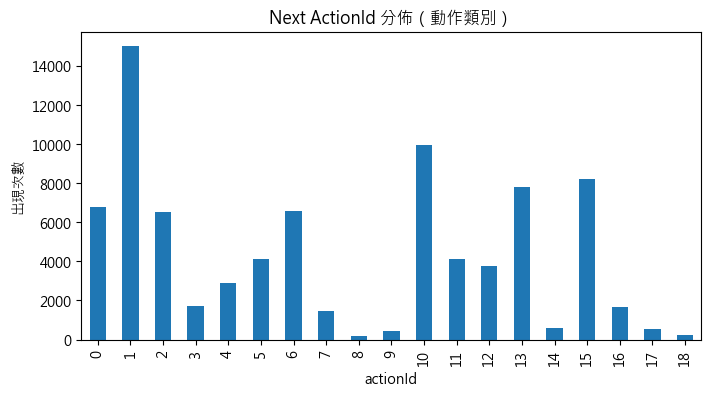

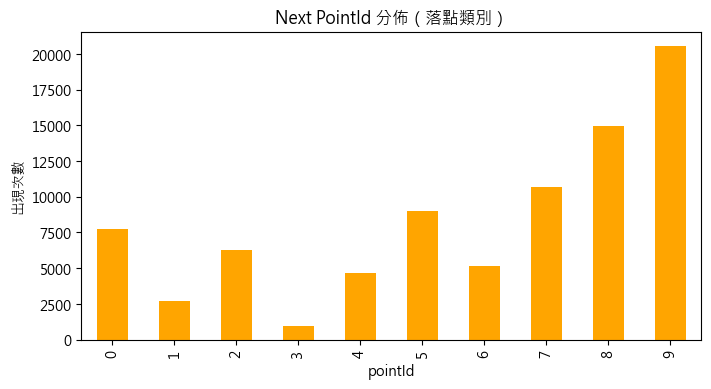

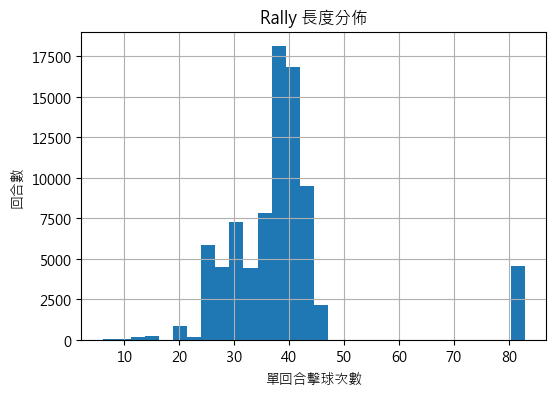

C:\Users\winni\AppData\Local\Temp\ipykernel_21300\2090643815.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comp = clean_train.groupby(bins)["next_actionId"].value_counts(normalize=True).unstack().fillna(0)


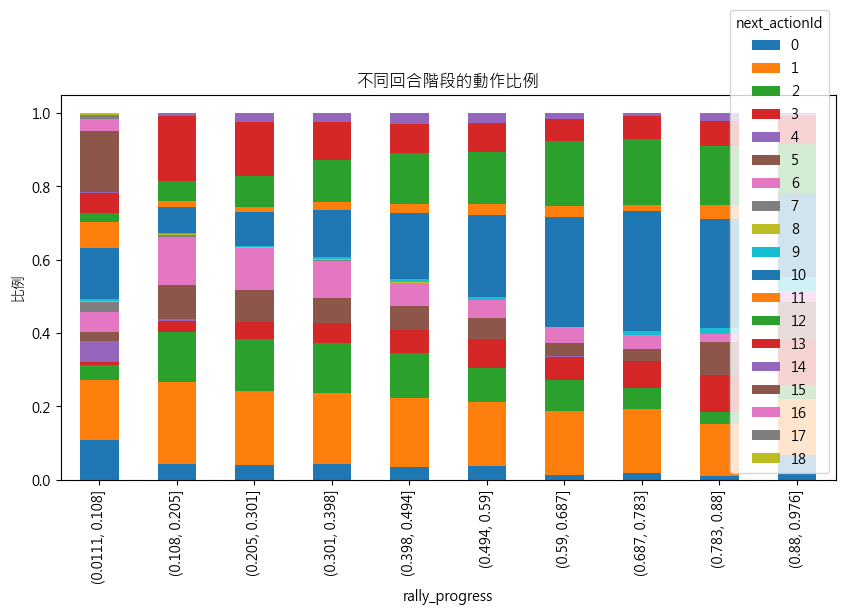

In [11]:
# 1️⃣ Next ActionId 分佈
if "next_actionId" in clean_train.columns:
    plt.figure(figsize=(8,4))
    clean_train["next_actionId"].value_counts().sort_index().plot(kind="bar")
    plt.title("Next ActionId 分佈（動作類別）")
    plt.xlabel("actionId")
    plt.ylabel("出現次數")
    plt.show()

# 2️⃣ Next PointId 分佈
if "next_pointId" in clean_train.columns:
    plt.figure(figsize=(8,4))
    clean_train["next_pointId"].value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title("Next PointId 分佈（落點類別）")
    plt.xlabel("pointId")
    plt.ylabel("出現次數")
    plt.show()

# 3️⃣ Rally 長度分佈
if "rally_length" in clean_train.columns:
    plt.figure(figsize=(6,4))
    clean_train["rally_length"].hist(bins=30)
    plt.title("Rally 長度分佈")
    plt.xlabel("單回合擊球次數")
    plt.ylabel("回合數")
    plt.show()

# 4️⃣ 不同回合階段的動作比例
if "rally_progress" in clean_train.columns and "next_actionId" in clean_train.columns:
    bins = pd.cut(clean_train["rally_progress"], bins=10)
    comp = clean_train.groupby(bins)["next_actionId"].value_counts(normalize=True).unstack().fillna(0)
    comp.plot(kind="bar", stacked=True, figsize=(10,5))
    plt.title("不同回合階段的動作比例")
    plt.ylabel("比例")
    plt.show()
